In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scipy.stats as scs

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

POSITION_CAT = {
    'Guard': 1,
    'Forward-Guard': 2,
    'Forward': 3,
    'Forward-Center': 4,
    'Center': 5
}


In [2]:
# Load data
with open('./data/players_shots_density_attempted.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/players_shots_density_made.pickle', 'rb') as f:
    players_shots_density_made = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load MFPCA results
with open('./data/MFPCA.pickle', 'rb') as f:
    mfpca = pickle.load(f)
with open('./data/scores.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/MFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

# Load functional distances
with open('./data/distance_functional.pickle', 'rb') as f:
    distance_functional = pickle.load(f)

# Load clustering results
with open('./data/clustering_kmedoids_data_driven.pickle', 'rb') as f:
    clustering = pickle.load(f)
with open('./data/distance_scores.pickle', 'rb') as f:
    distance_scores = pickle.load(f)

In [3]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')
scores['cluster'] = clustering['pred'] + 1

In [7]:
clustering

{'centers': array([[-0.26250999, -0.36986548,  1.01498351, -0.45961875],
        [ 0.1858385 , -0.41567933,  0.12688759,  0.72523356],
        [-0.33438628,  0.57903059, -0.2142262 , -0.05129187]]),
 'idx_centers': [133, 165, 146],
 'pred': array([2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0,
        2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 1, 1, 2, 1, 2, 2, 1,
        1, 1, 0, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 2, 2, 0, 1, 1, 0, 1, 0,
        2, 1, 1, 1, 0, 1, 2, 0, 2, 2, 1, 1, 0, 2, 1, 1, 0, 1, 2, 2, 2, 1,
        1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2,
        1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 1, 1, 0, 1,
        2, 0, 0, 2, 2, 1, 2, 1, 2, 2, 0, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1,
        1, 2, 1, 2, 1, 2, 1, 0, 0, 1, 2, 1, 1, 2, 1, 0, 0, 1, 2])}

In [8]:
# Re-order clusters
# 1 -> 1 / 3 -> 2 / 4 -> 3 / 2 -> 4 / 5 -> 5
clusters = np.repeat(0, len(scores))
clusters[clustering['pred'] + 1 == 1] = 1
clusters[clustering['pred'] + 1 == 2] = 2
clusters[clustering['pred'] + 1 == 3] = 3
#clusters[clustering['pred'] + 1 == 4] = 3
#clusters[clustering['pred'] + 1 == 5] = 5
# Re-order medoids
# Old: clustering['idx_centers'] = [71, 124, 146, 14, 77]
medoids = [133, 165, 146]

In [9]:
for i in np.arange(3):
    print(scores[clusters == (i + 1)]['POSITION_'].value_counts())

POSITION_
Forward           18
Forward-Guard     12
Guard              8
Forward-Center     3
Name: count, dtype: int64
POSITION_
Guard             29
Forward           10
Forward-Center    10
Forward-Guard      7
Center             1
Name: count, dtype: int64
POSITION_
Guard             31
Forward           15
Forward-Center    12
Center            12
Forward-Guard      5
Name: count, dtype: int64


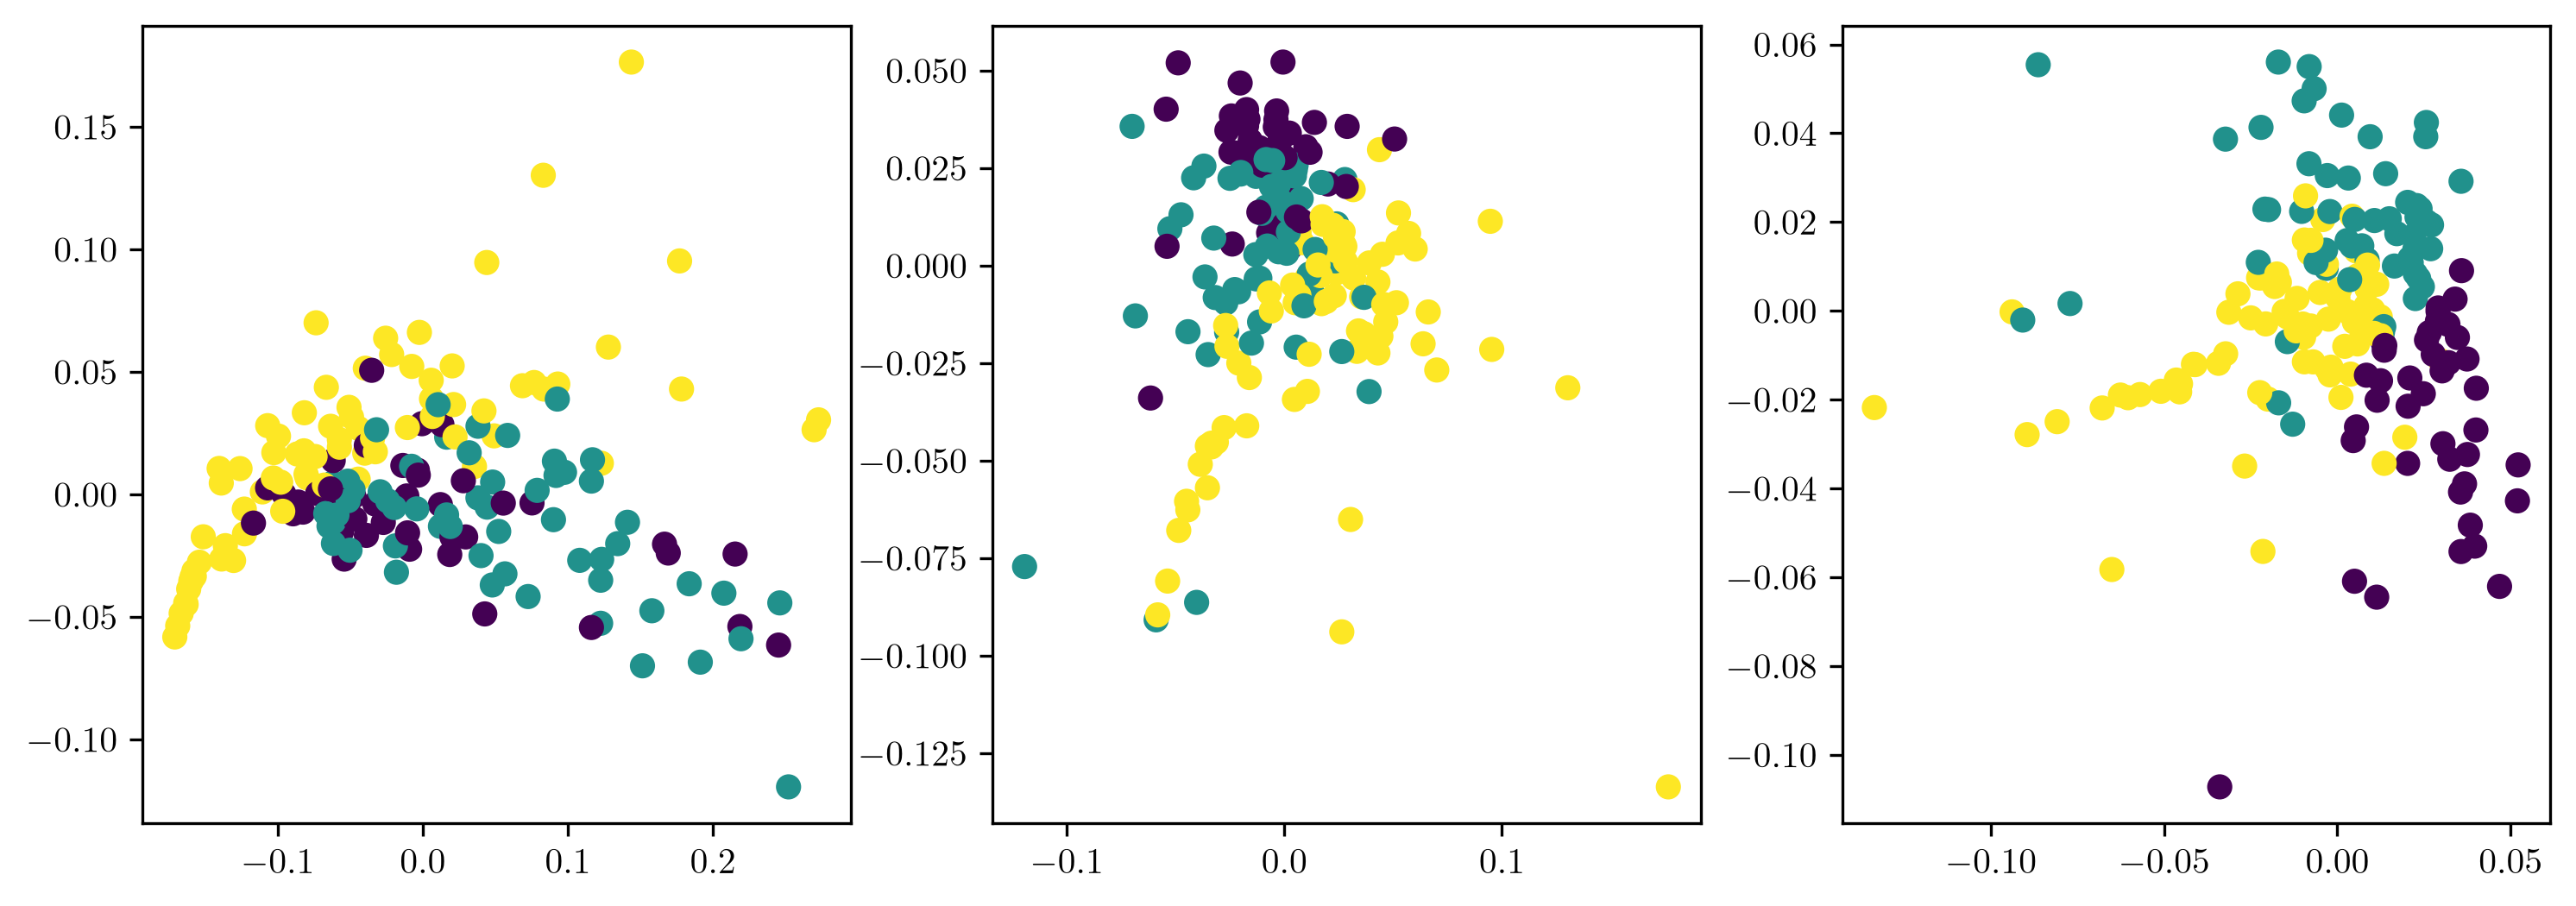

In [10]:
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax[0].scatter(scores[0], scores[1], c=clustering['pred'])
ax[1].scatter(scores[1], scores[2], c=clustering['pred'])
ax[2].scatter(scores[2], scores[3], c=clustering['pred'])

plt.show()

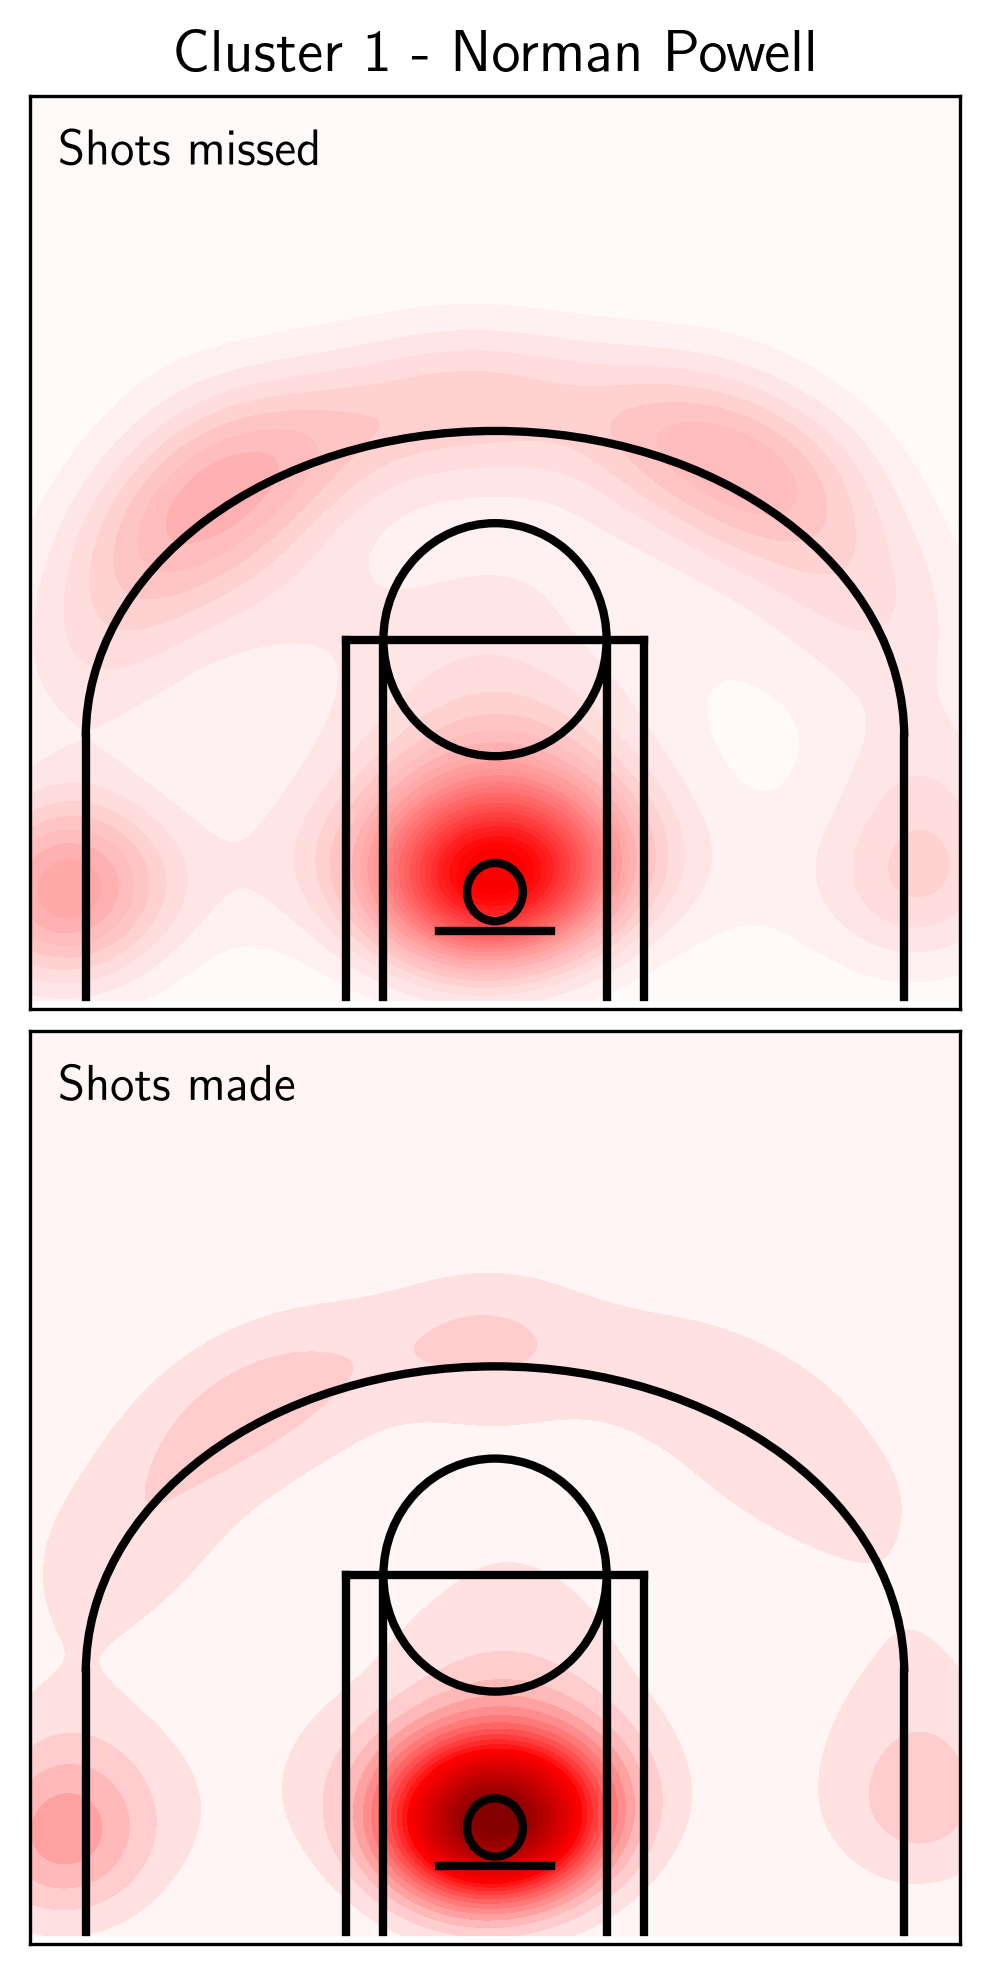

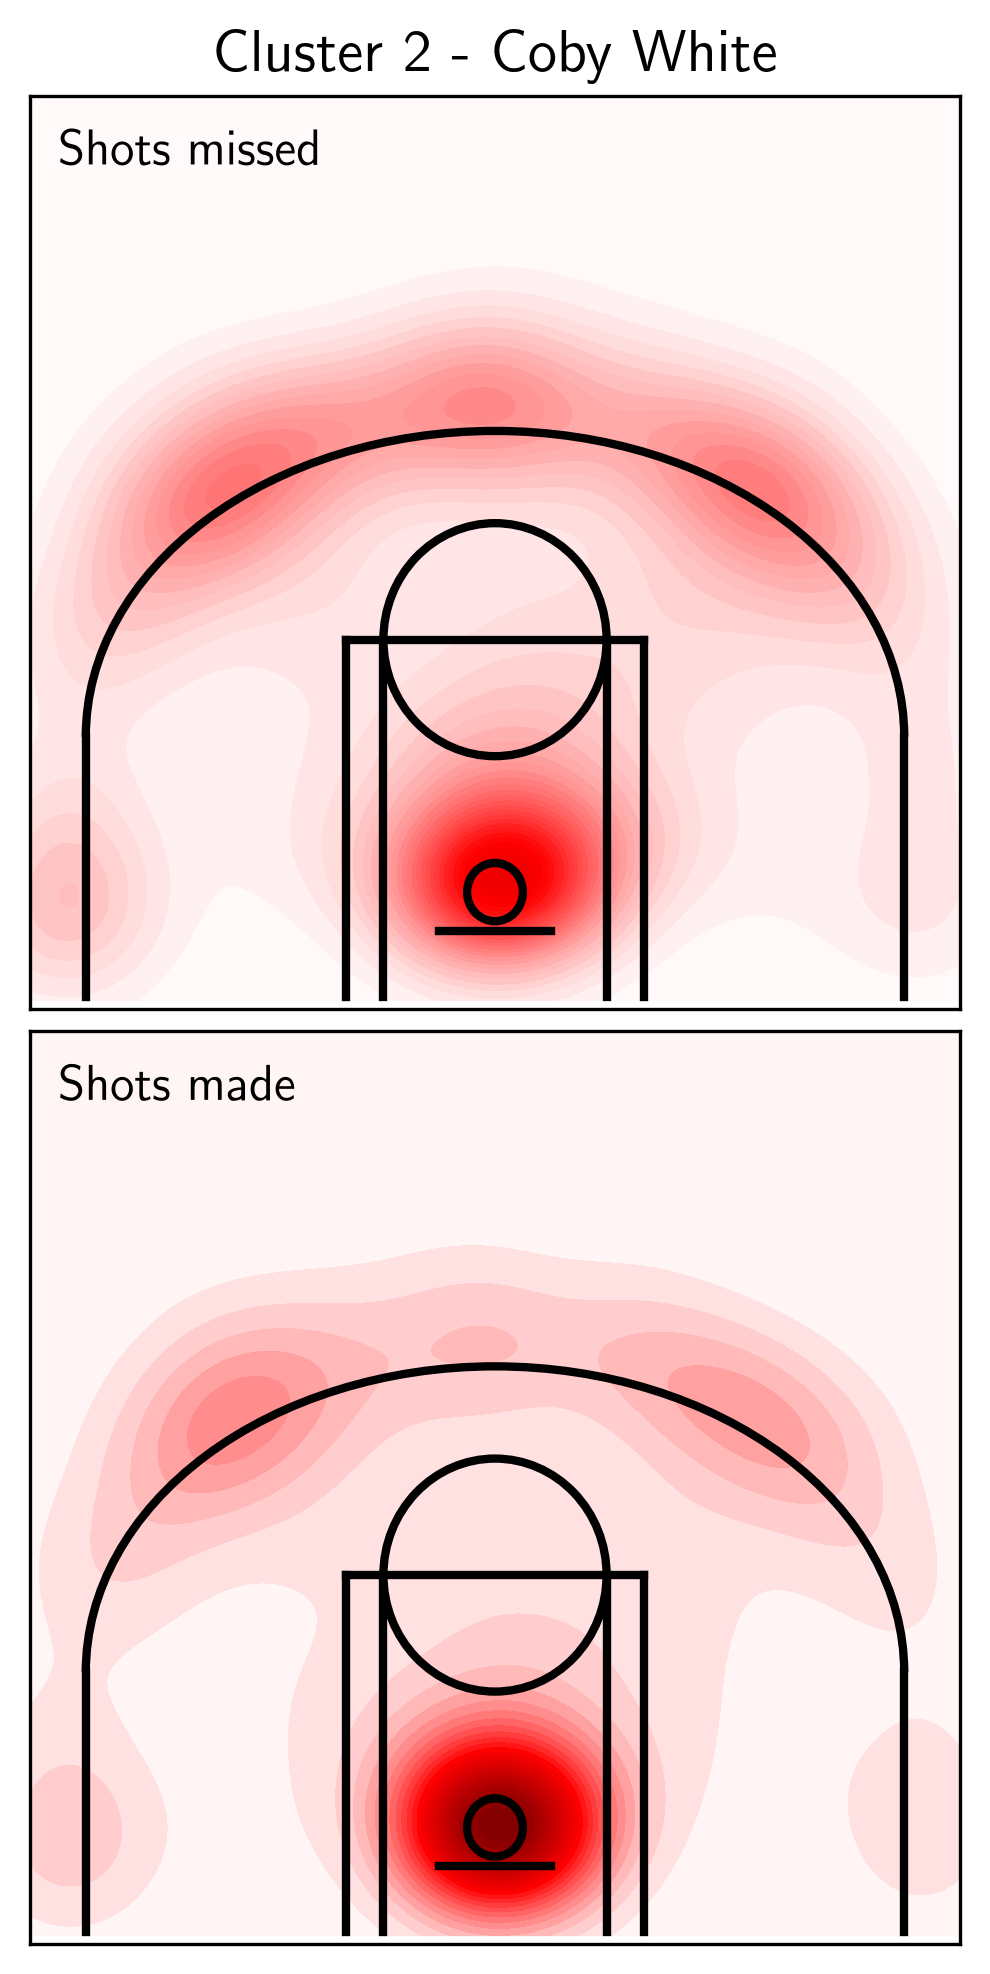

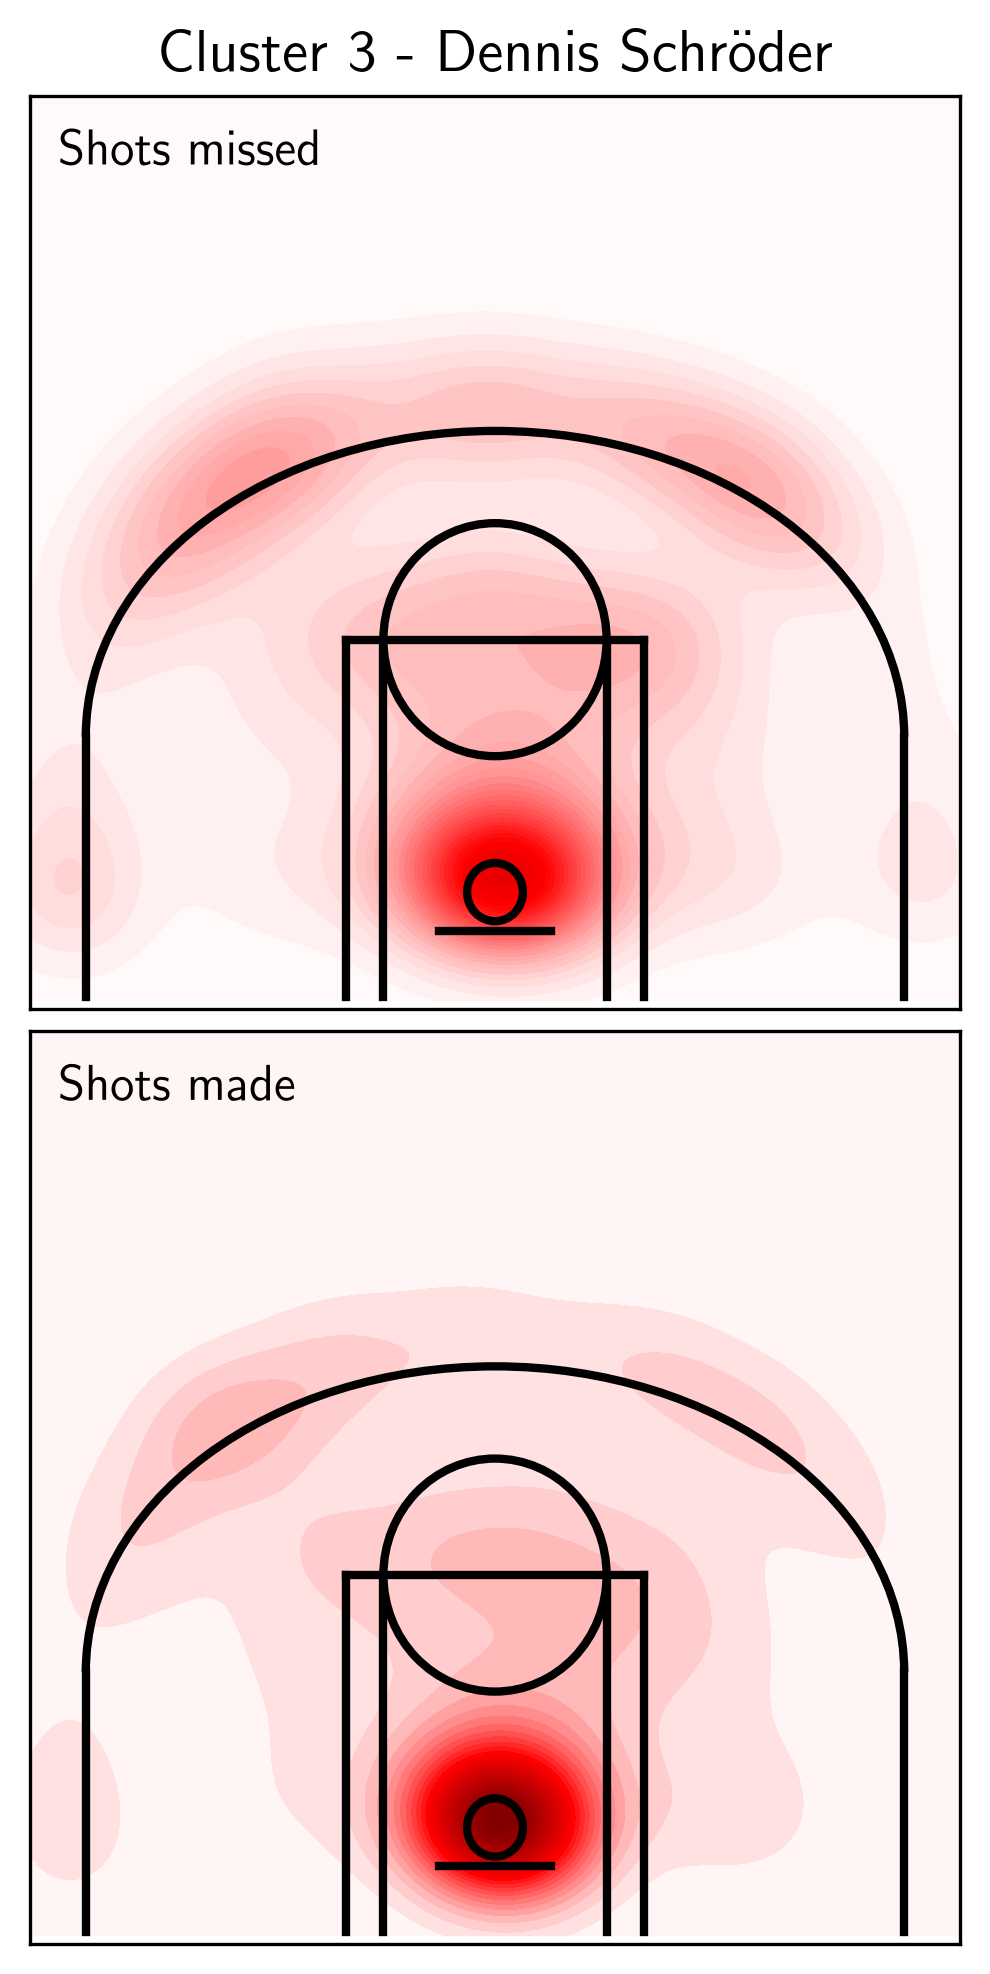

In [11]:
for idx_c, idx_p in enumerate(medoids):
    name = scores.iloc[idx_p]['PLAYER_NAME']
    fig, ax = plt.subplots(
        2, 1,
        figsize=(4, 8),
        facecolor='white',
        edgecolor='black',
        dpi=300
    )
    ax[0], ax[1] = ShotCharts.shots_chart_2(
        ax[0], ax[1],
        players_shots_density, players_shots_density_made,
        name, 'Shots missed', 'Shots made', add_headshot=False
    )
    ax[0].set_title(f"Cluster {idx_c + 1} - {name}", fontsize='x-large')
    
    plt.subplots_adjust(hspace=0.025)
    plt.savefig(
        f'./figures/kmedoids_average_player_{idx_c + 1}-normalized-data.eps',
        transparent=True, format='eps'
    )

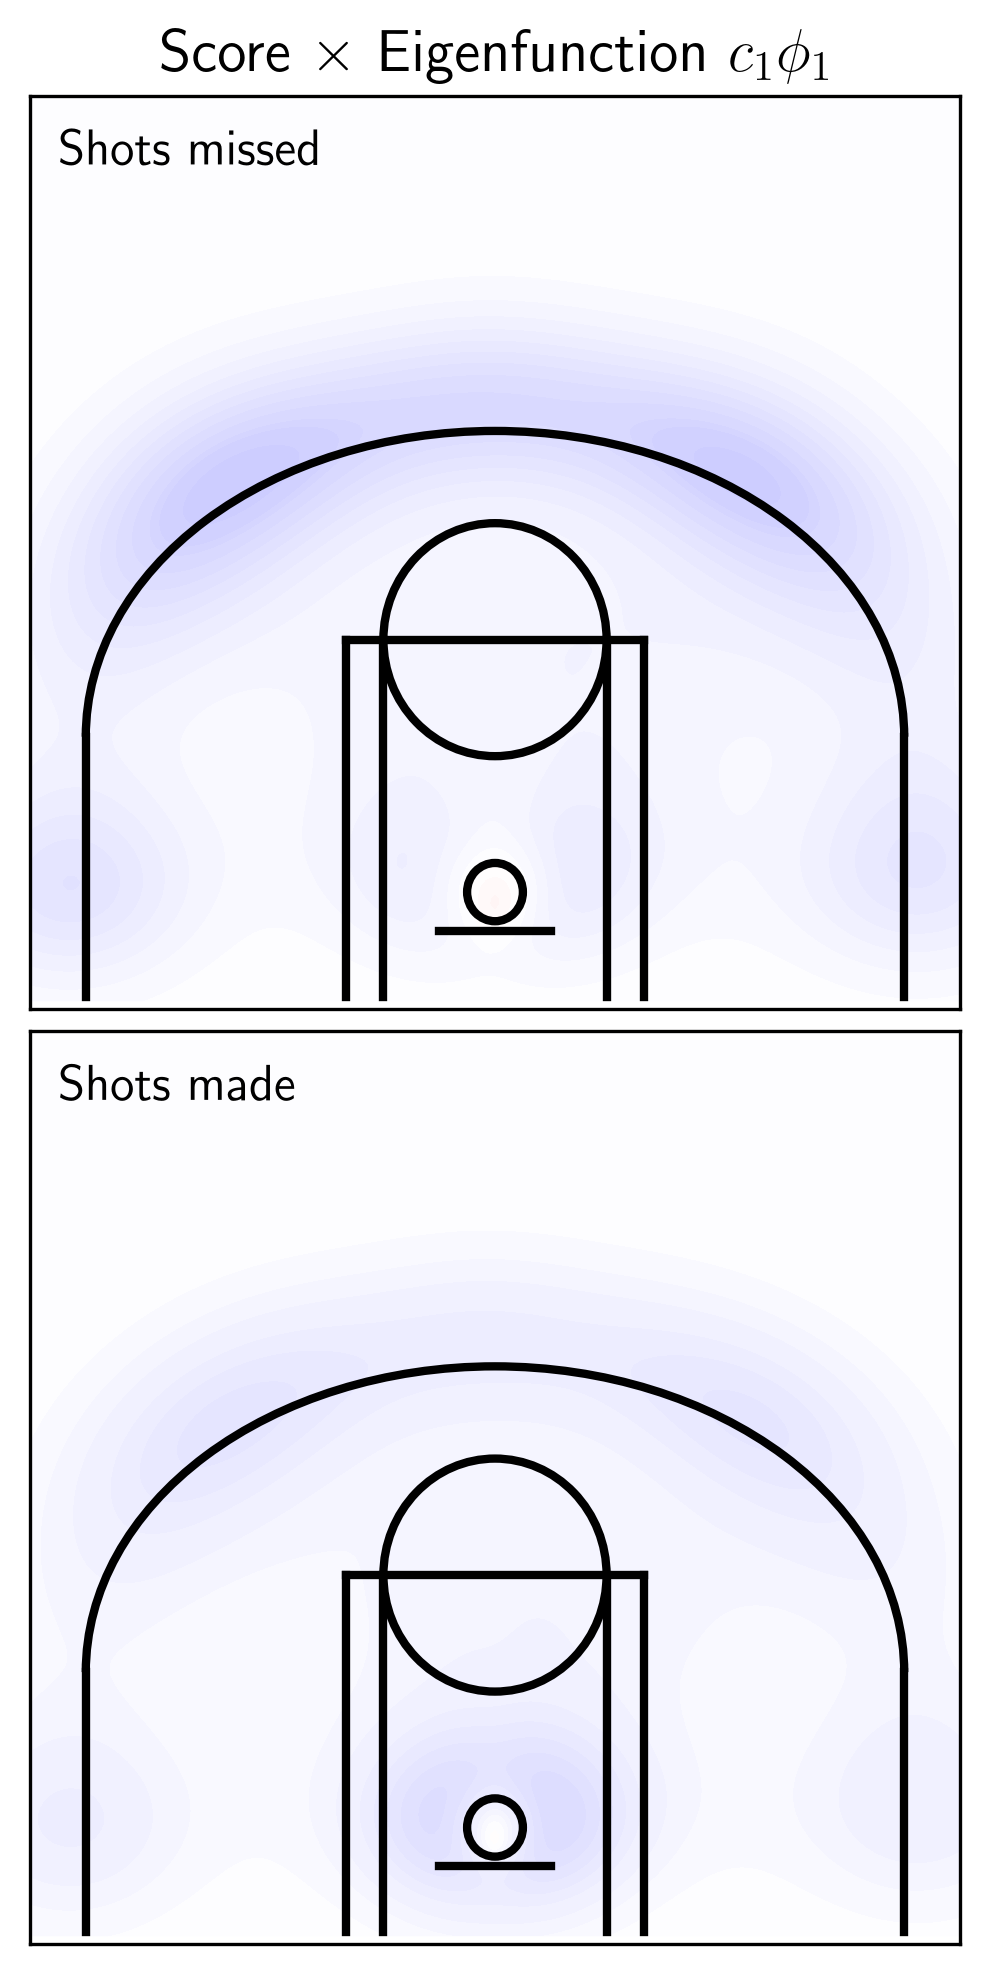

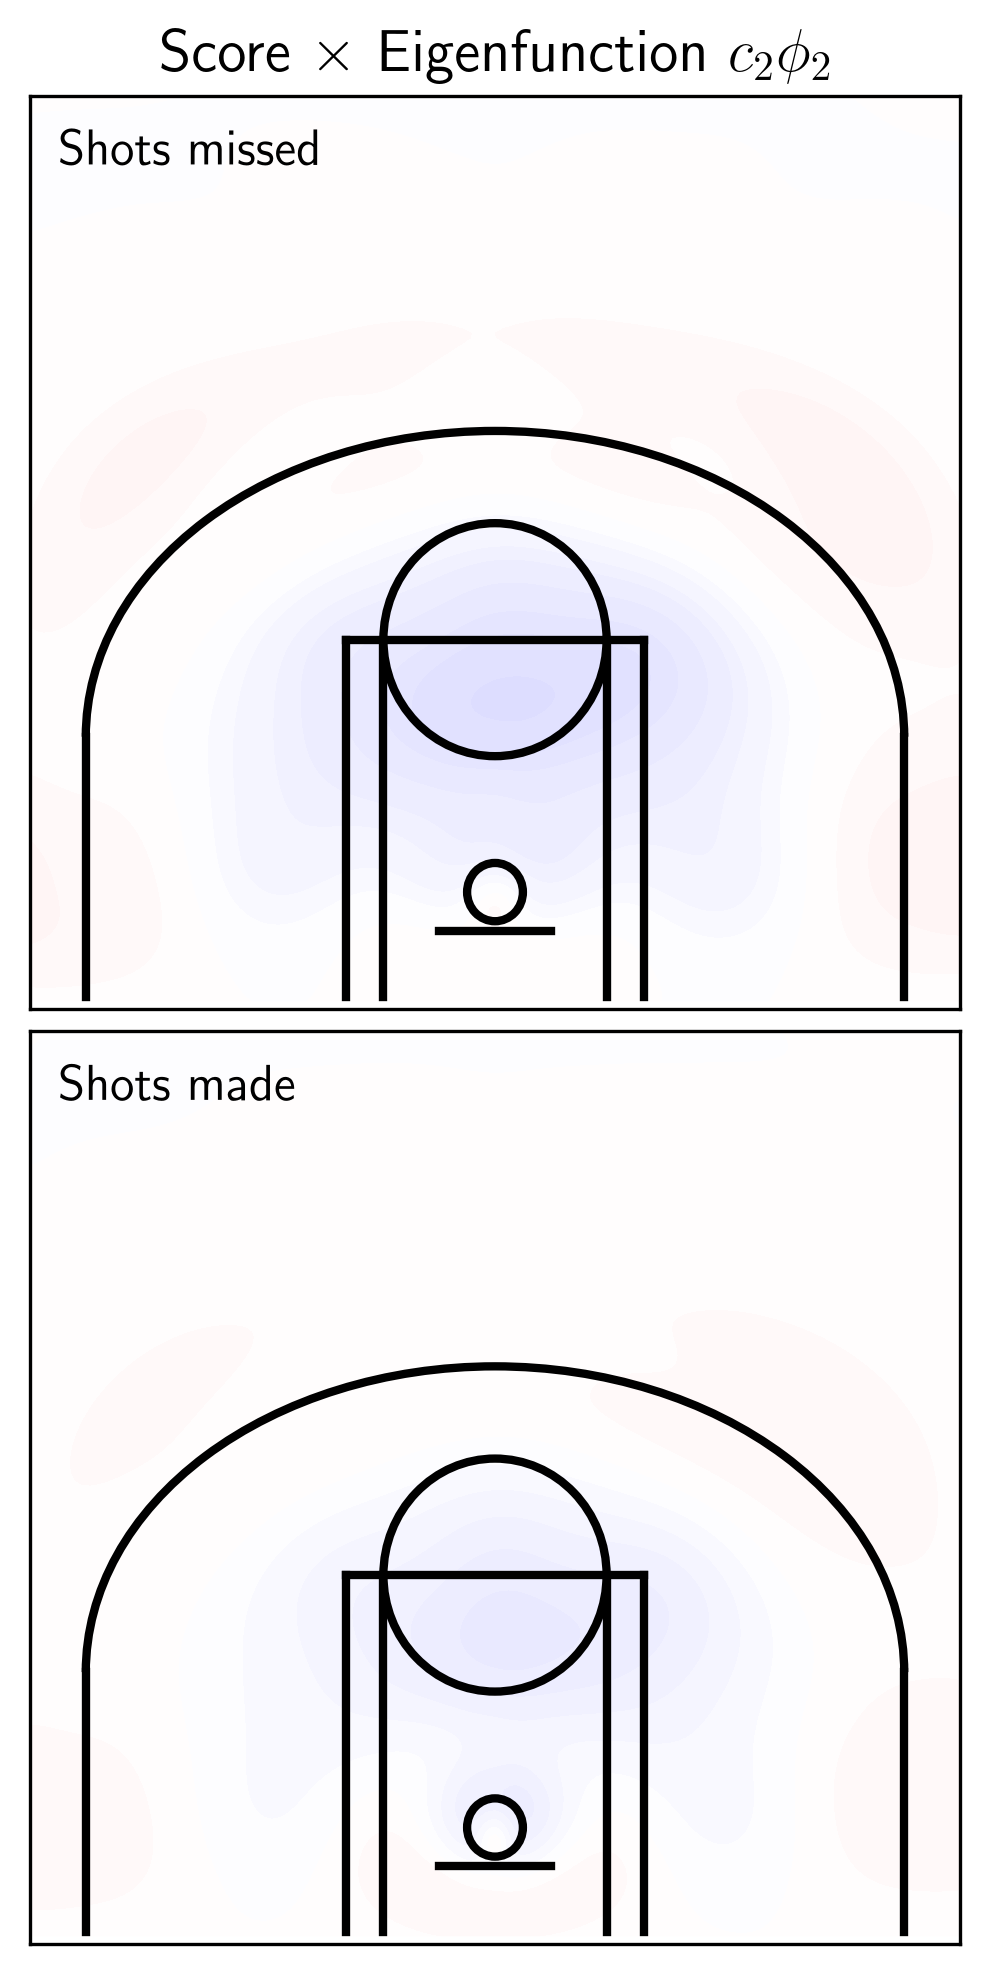

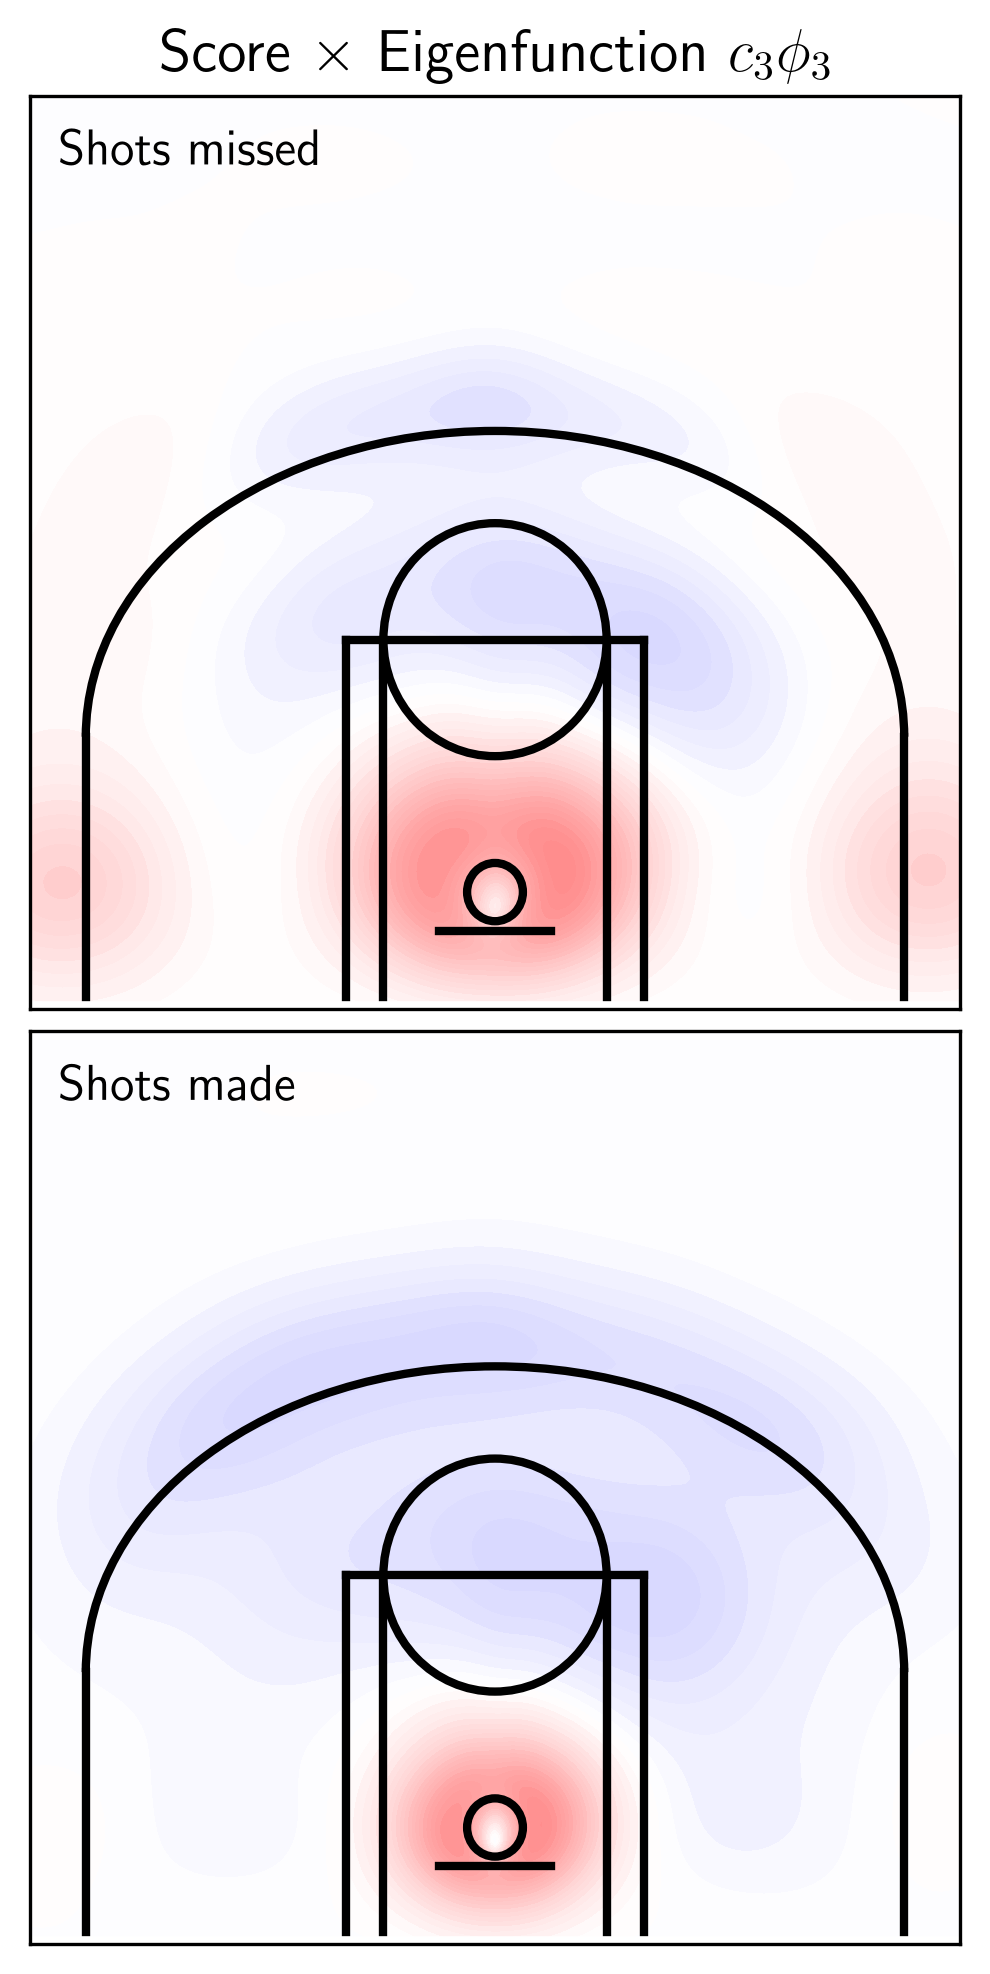

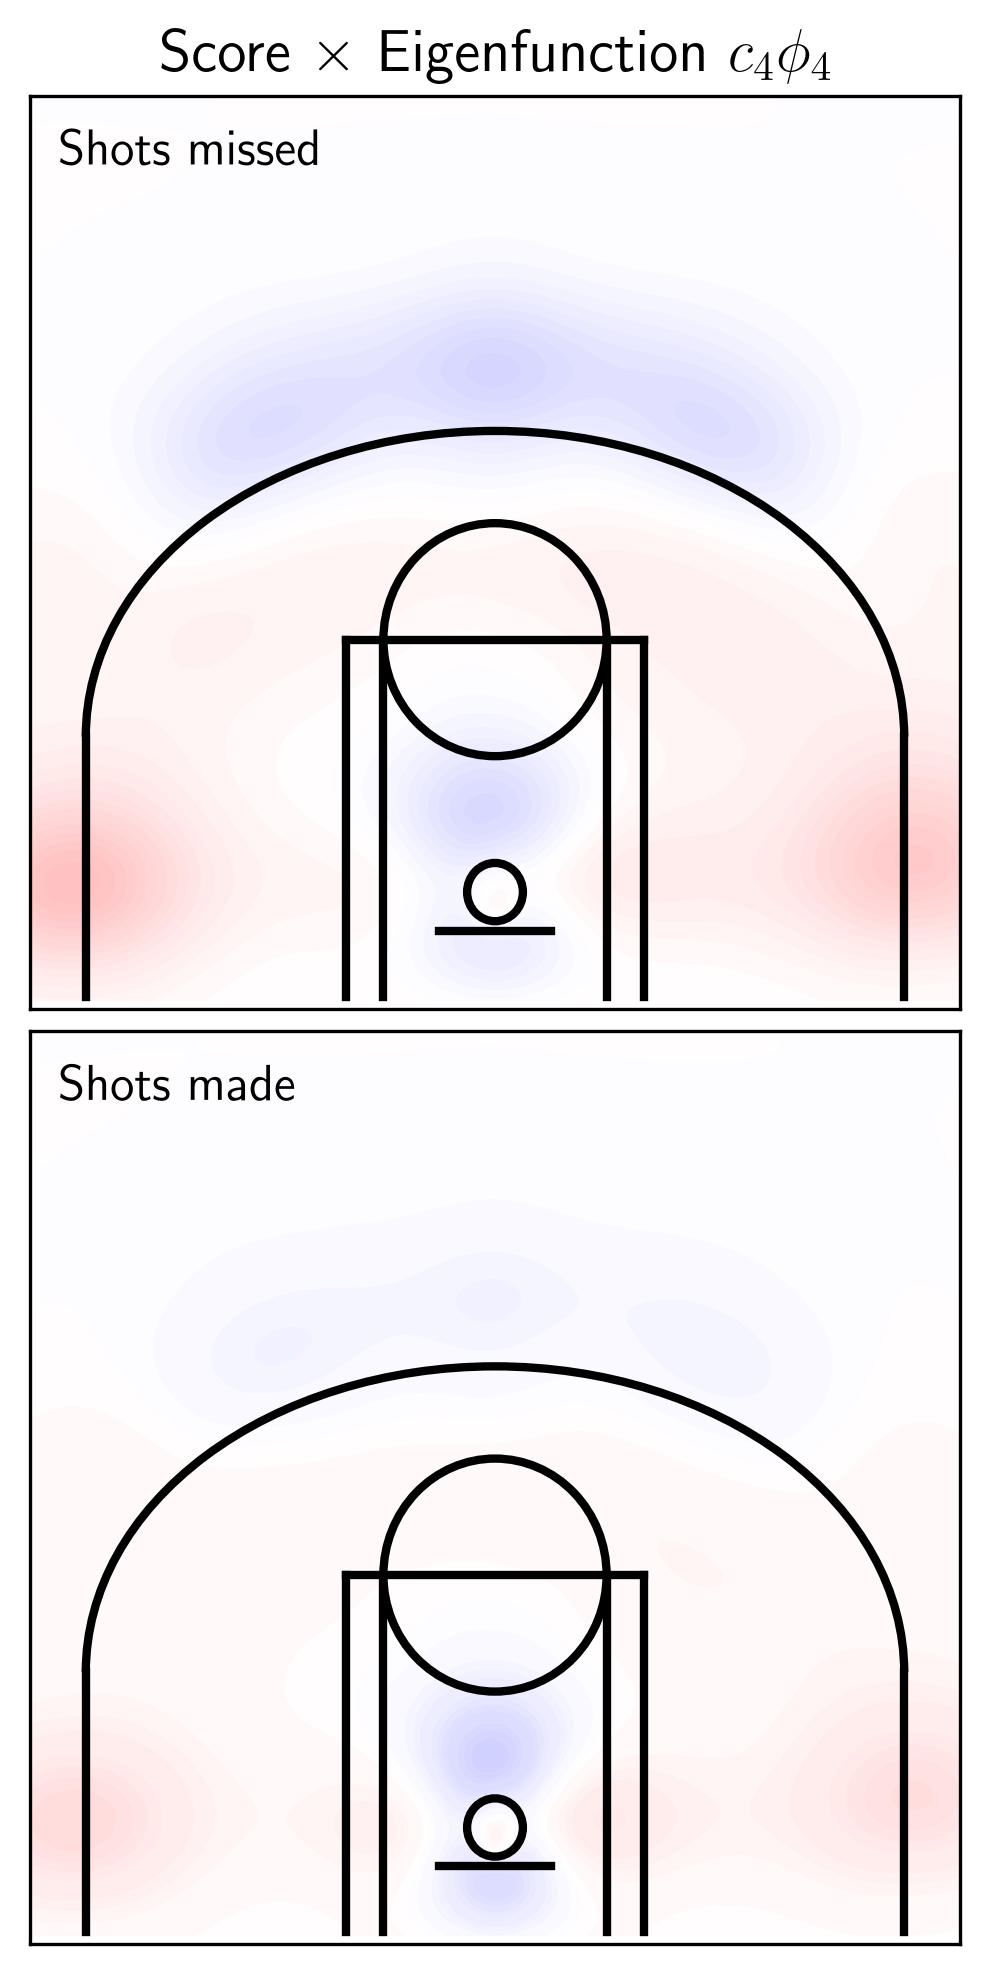

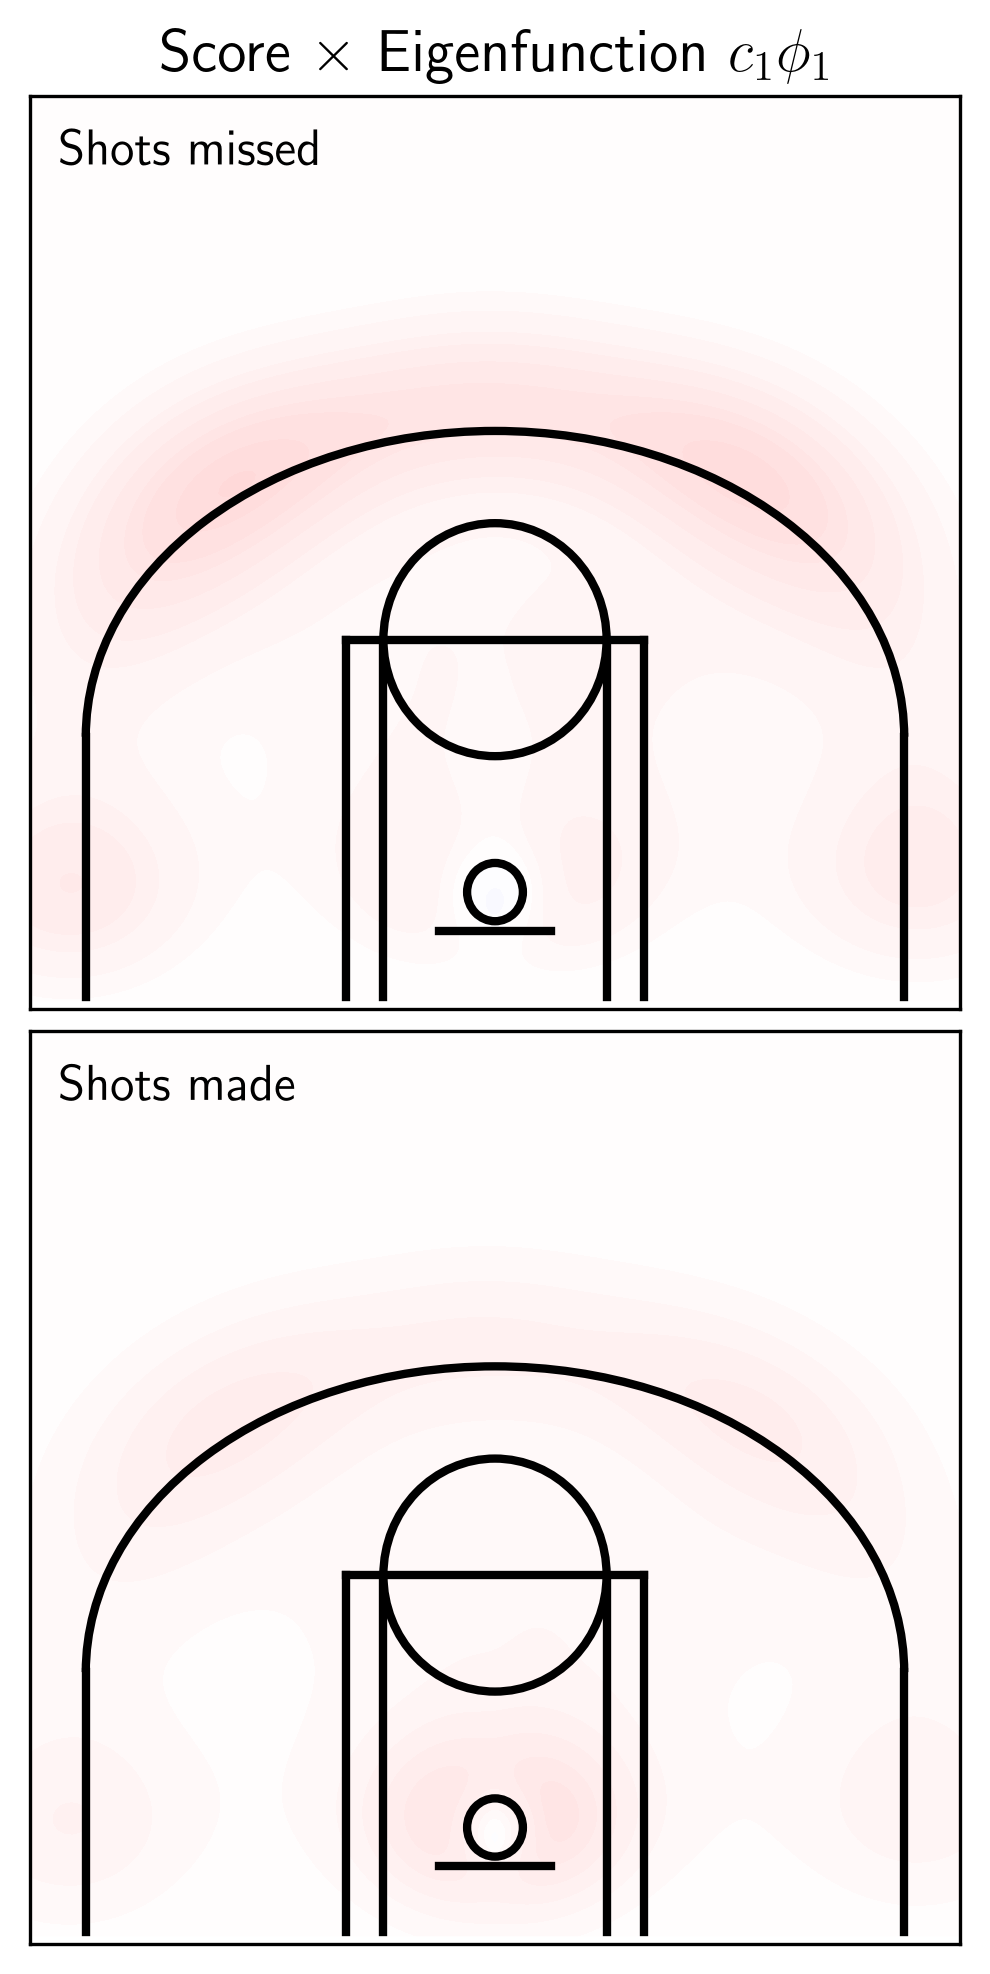

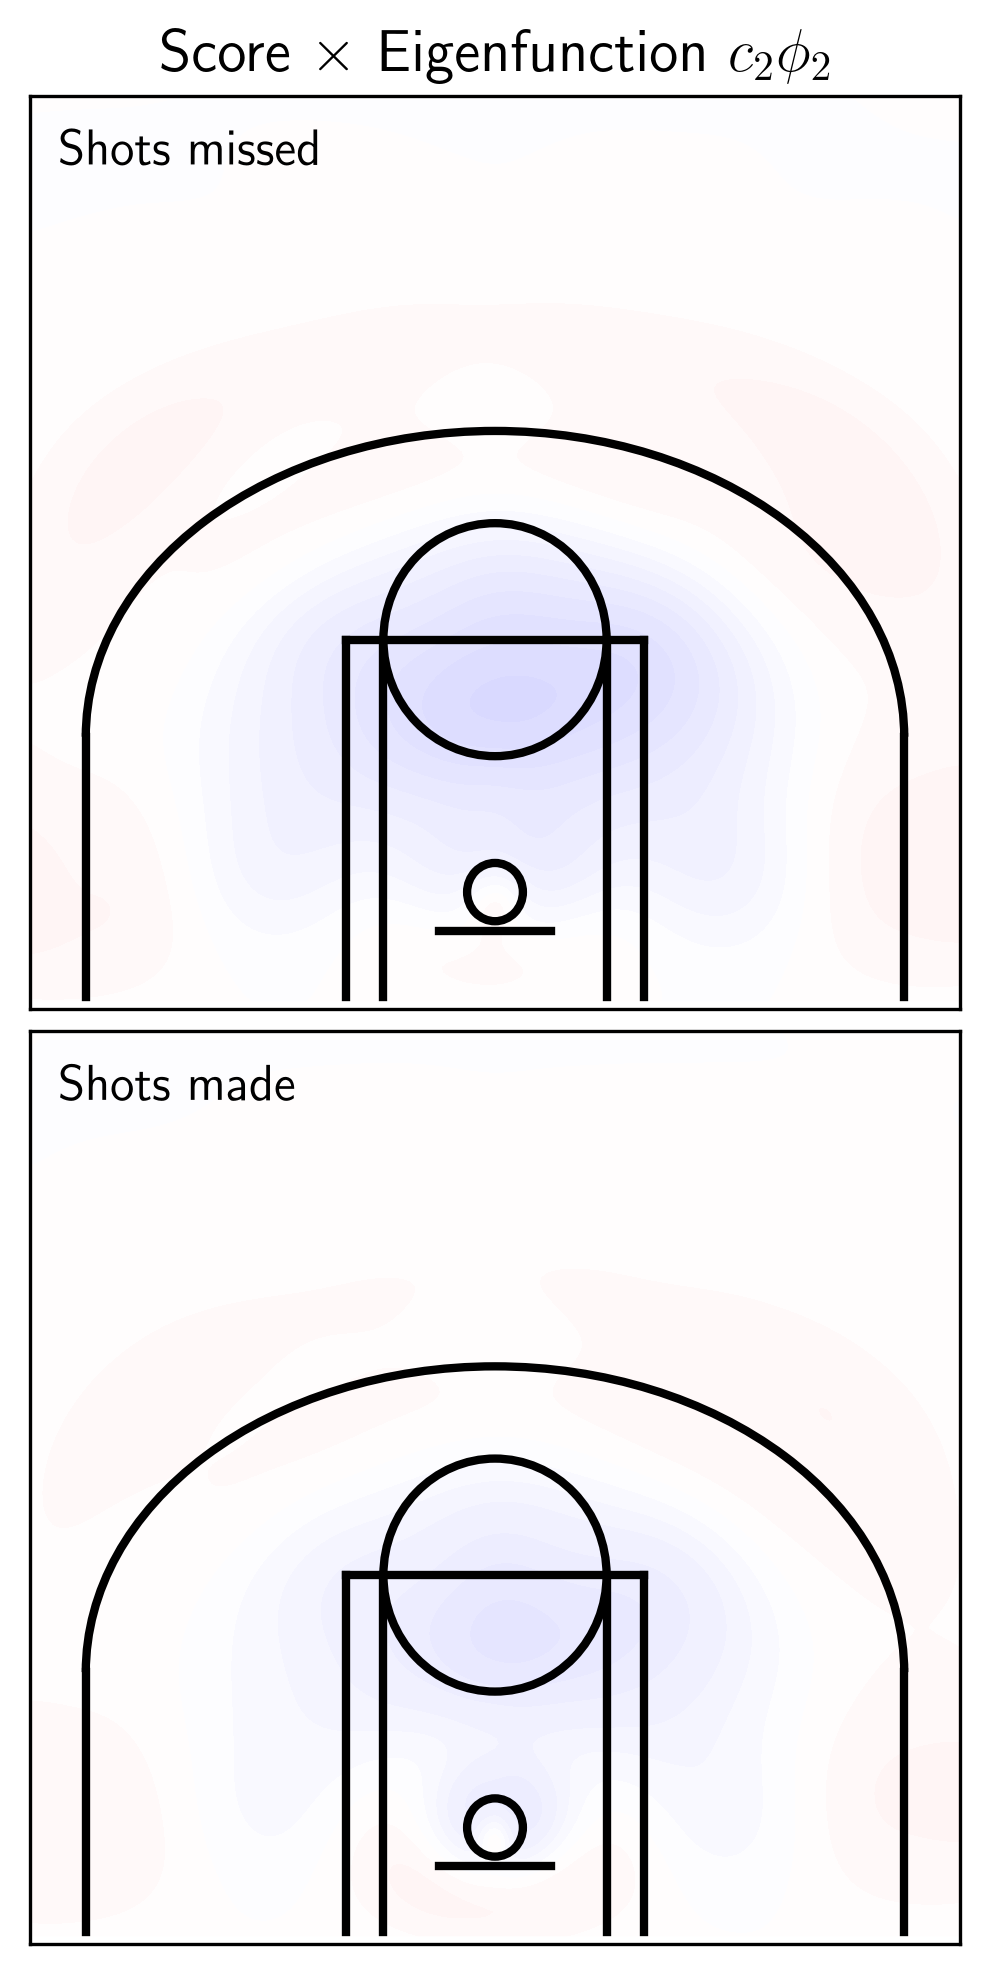

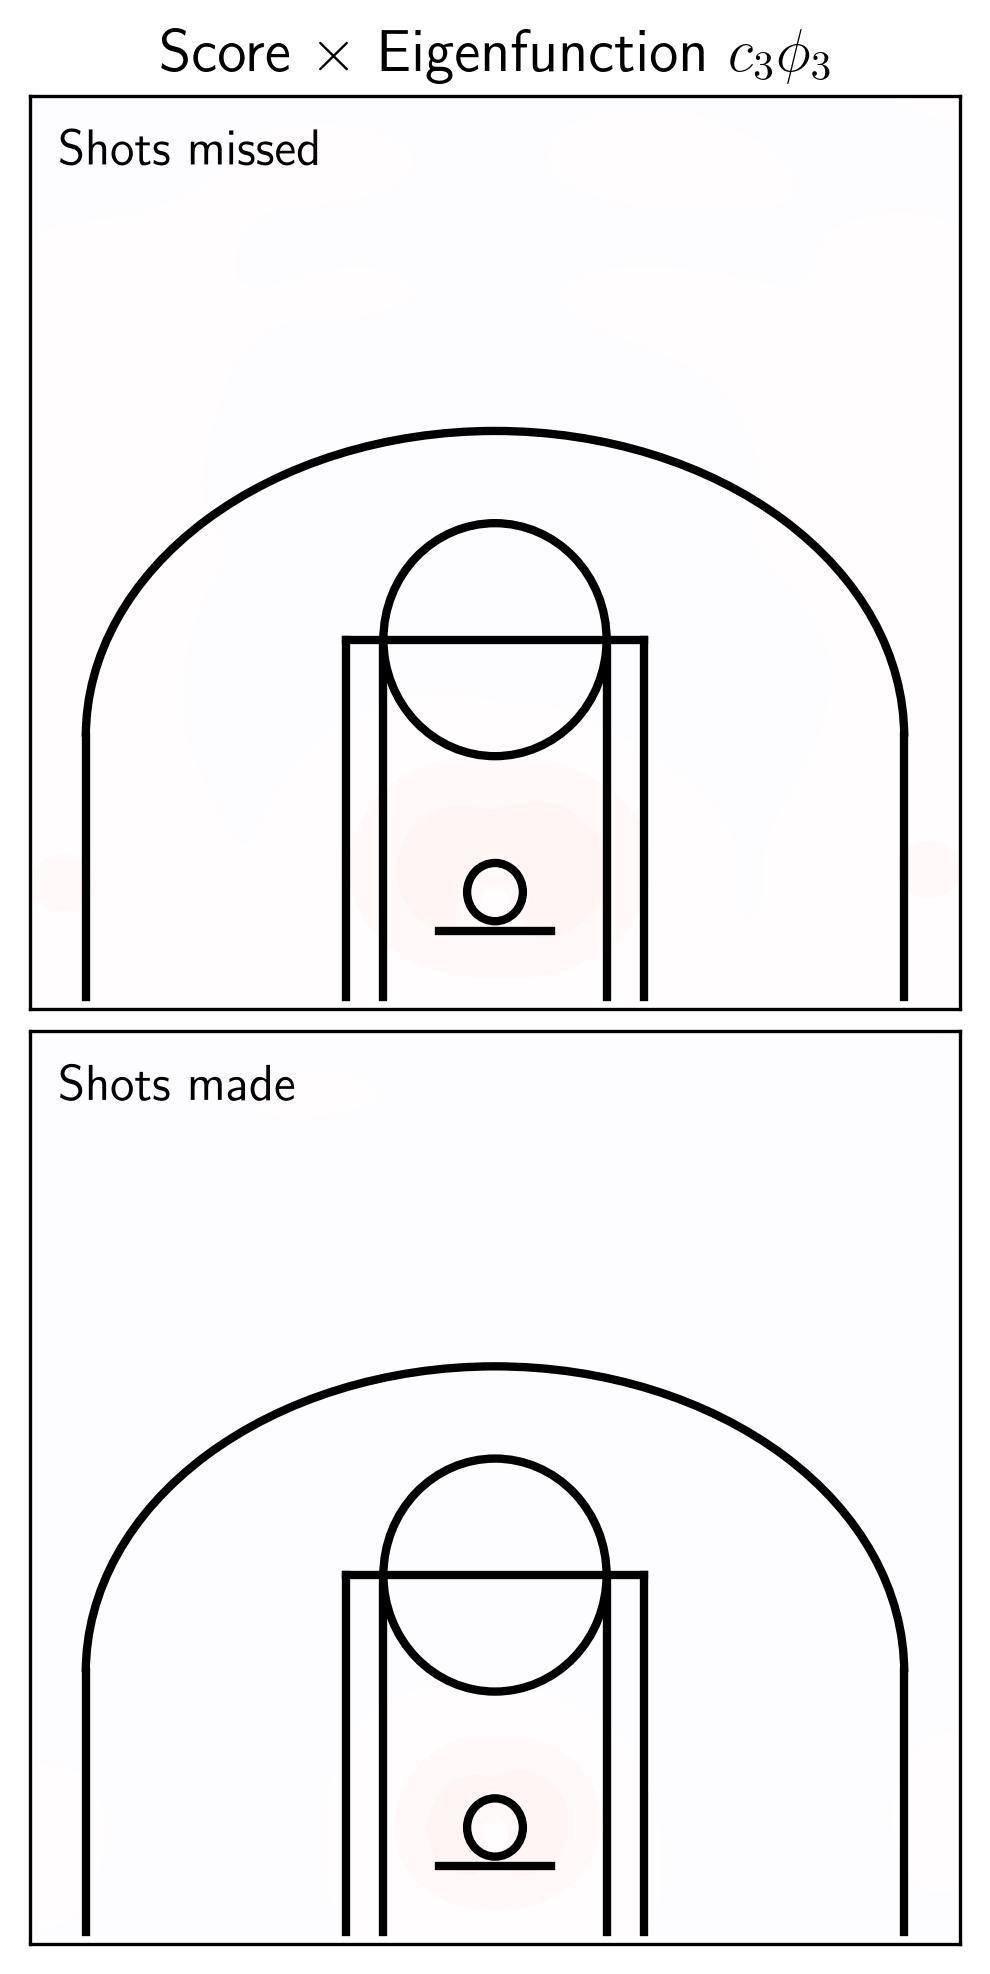

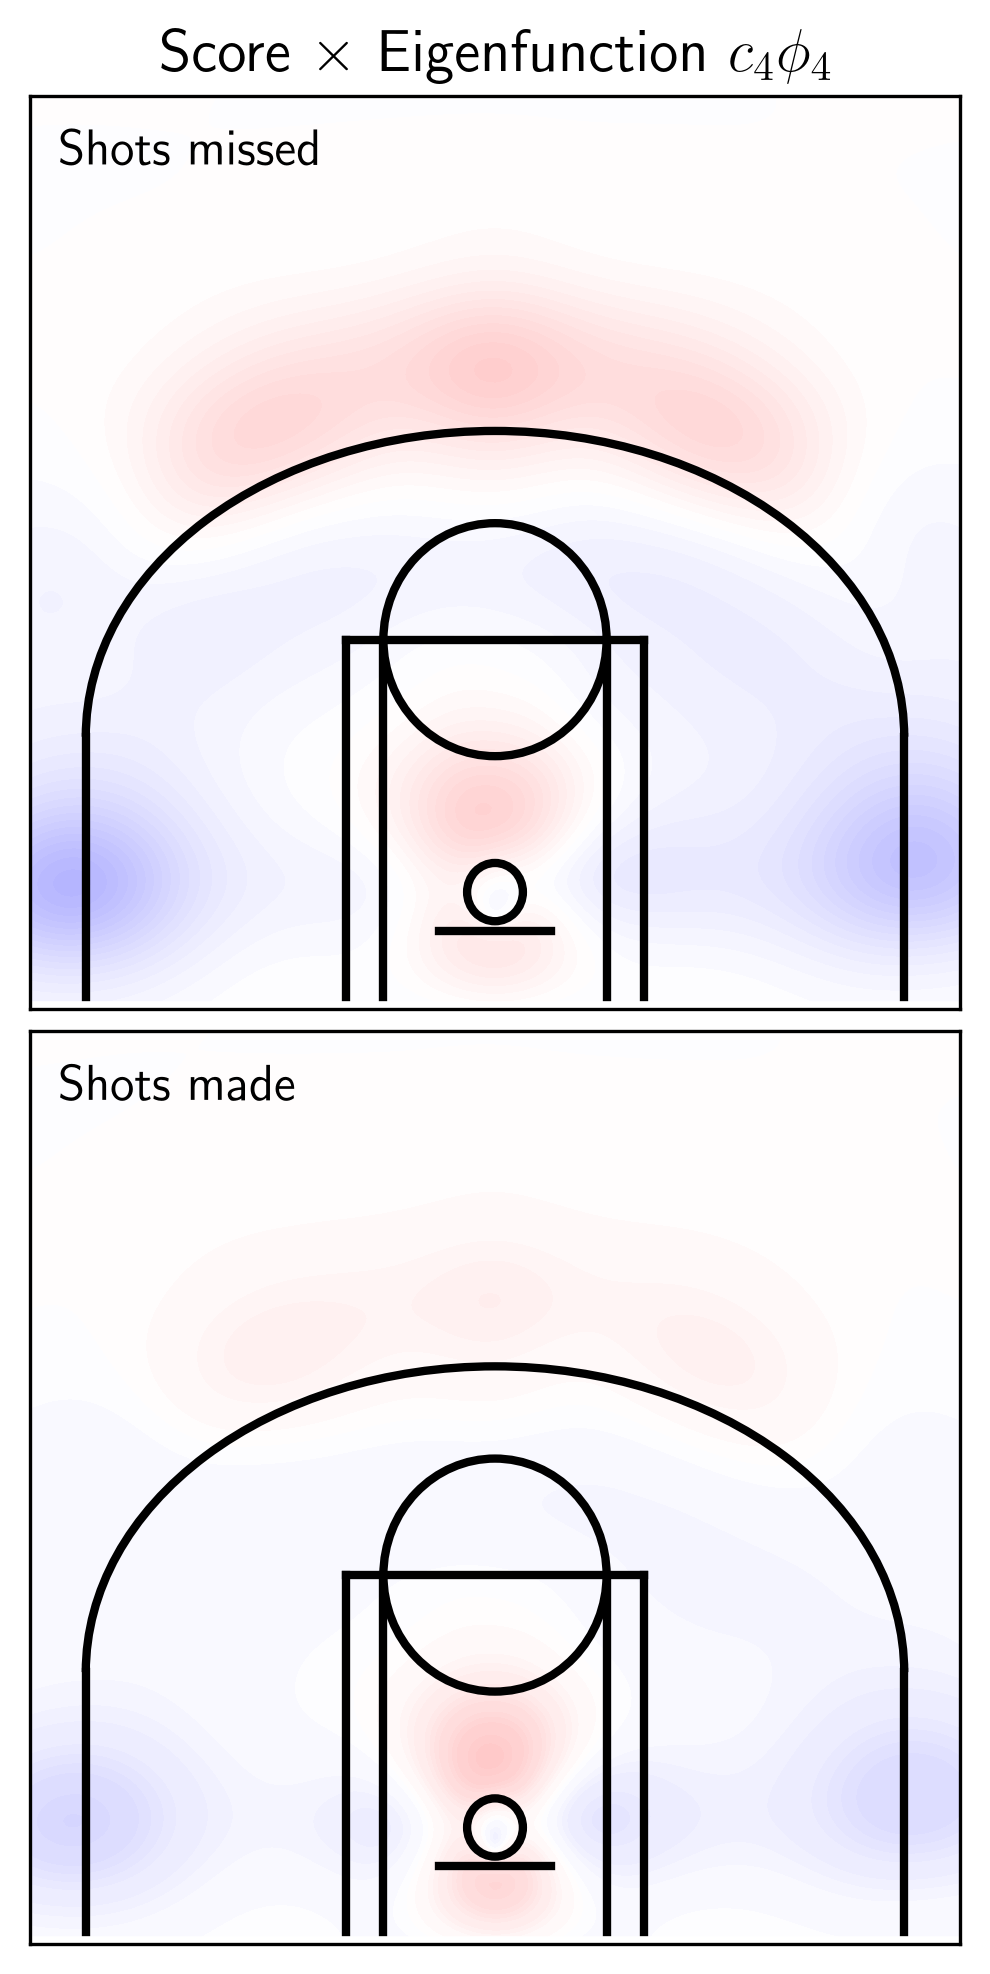

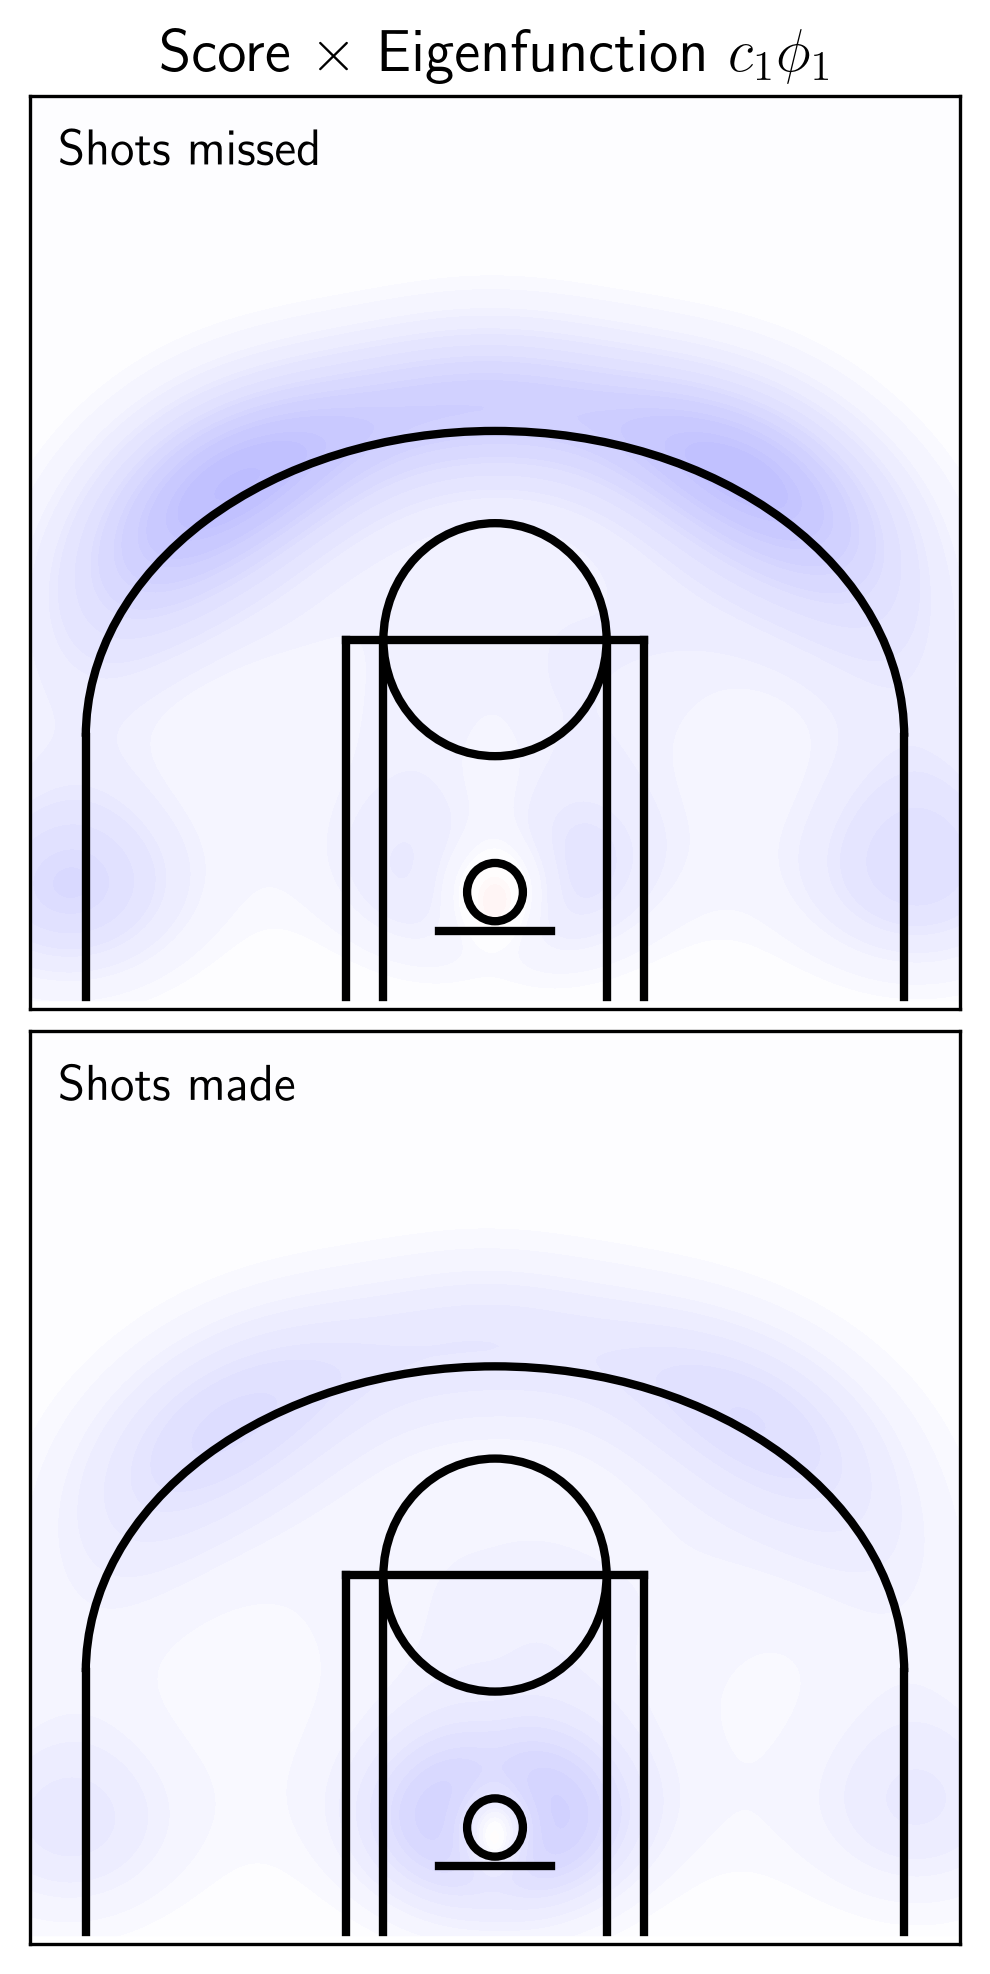

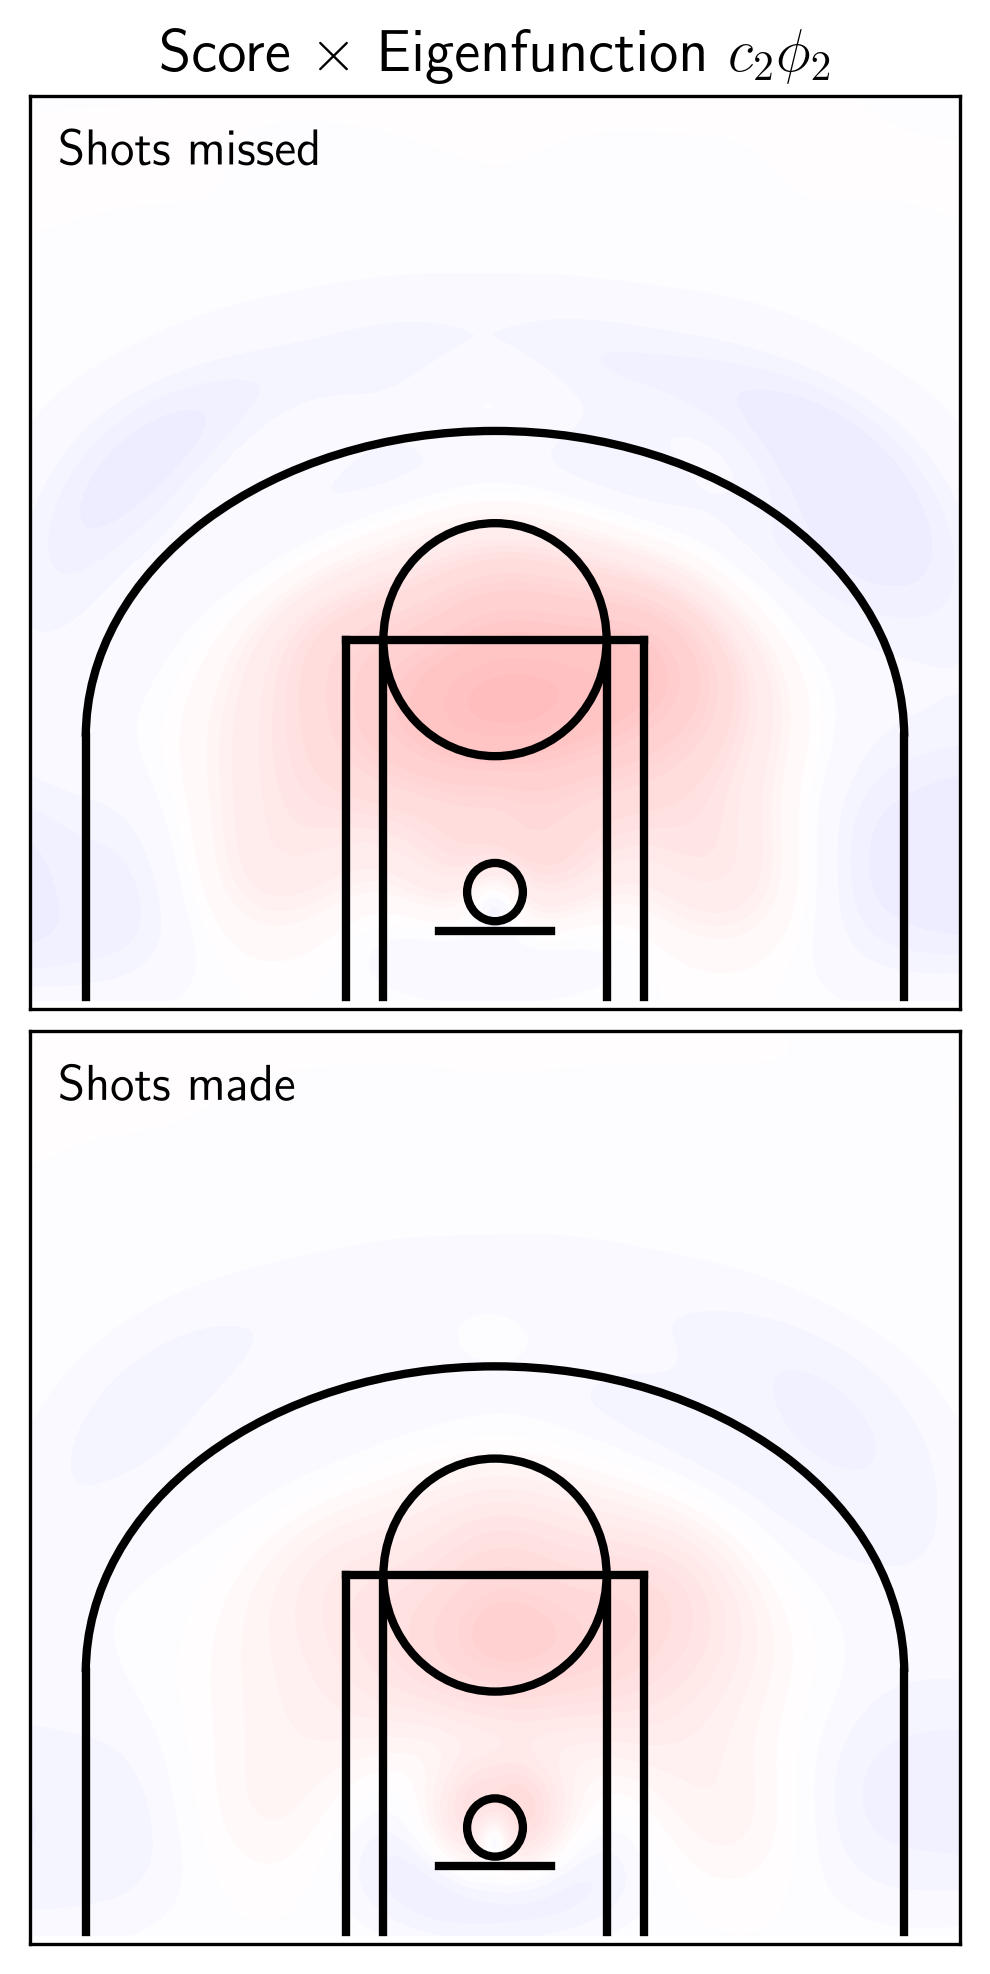

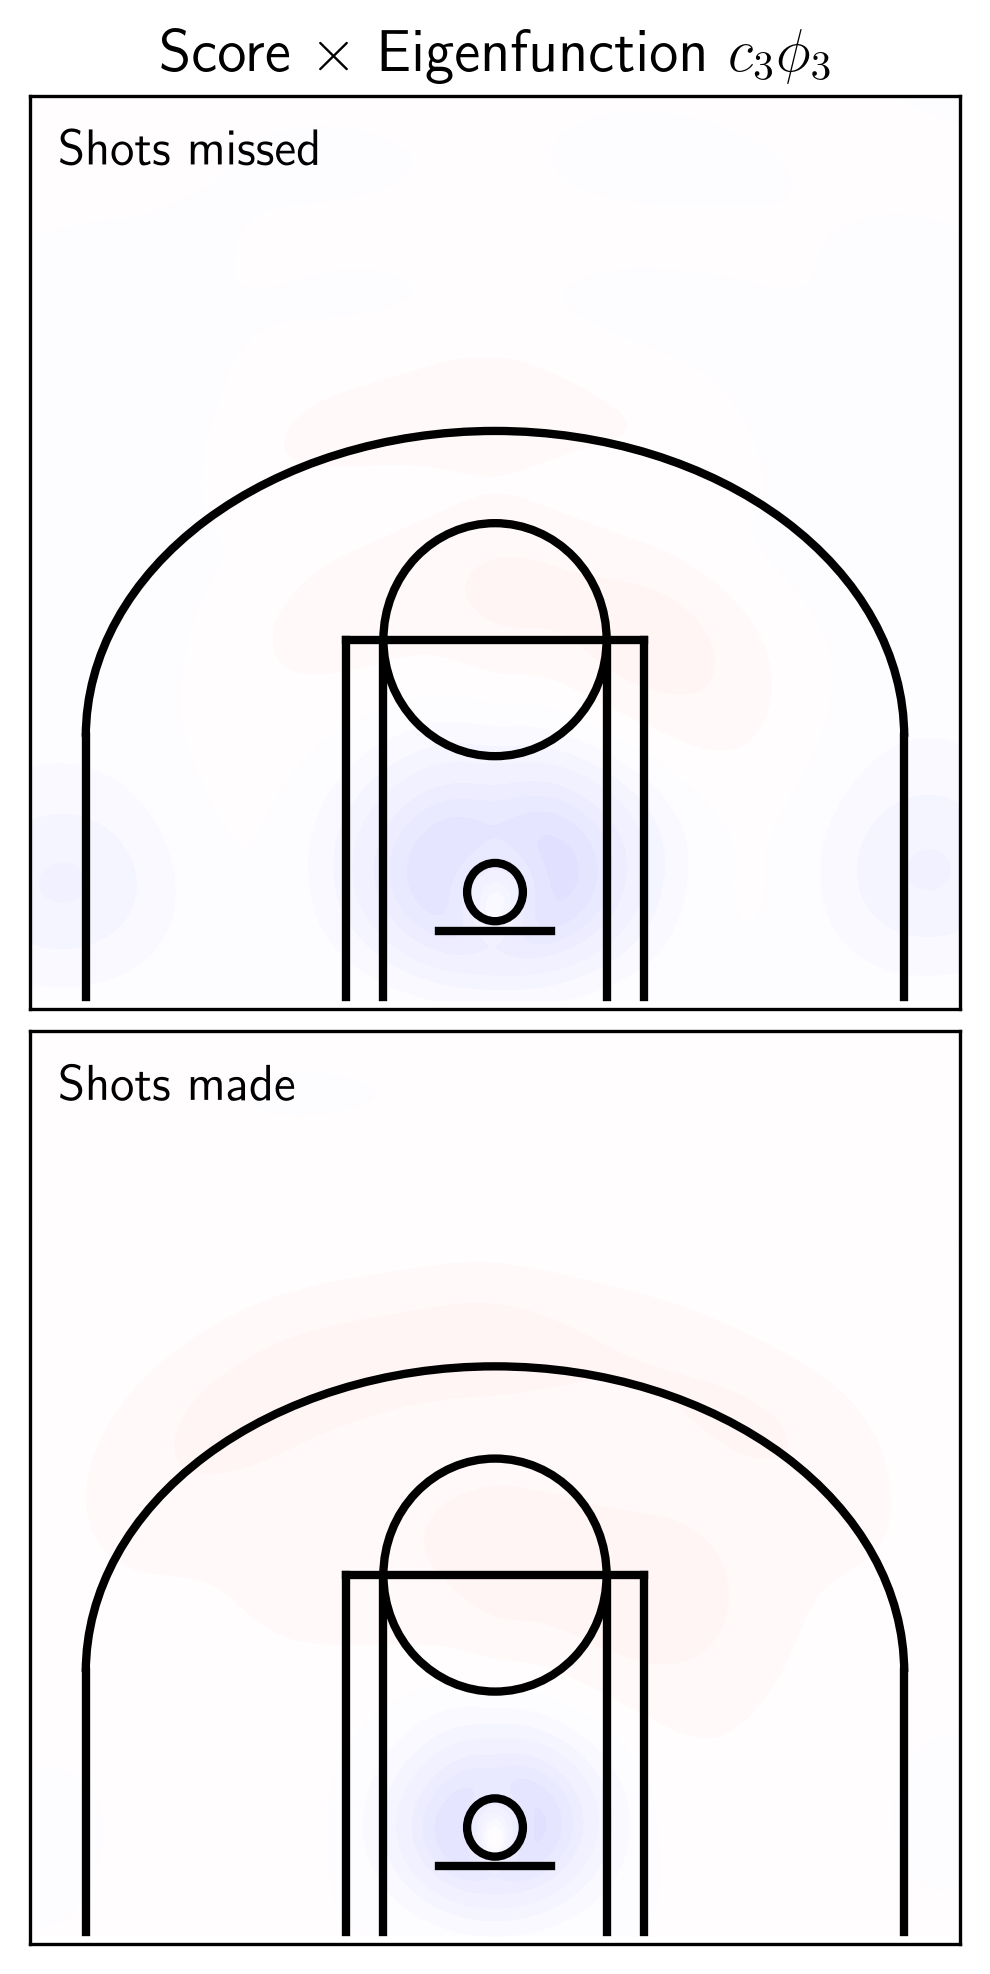

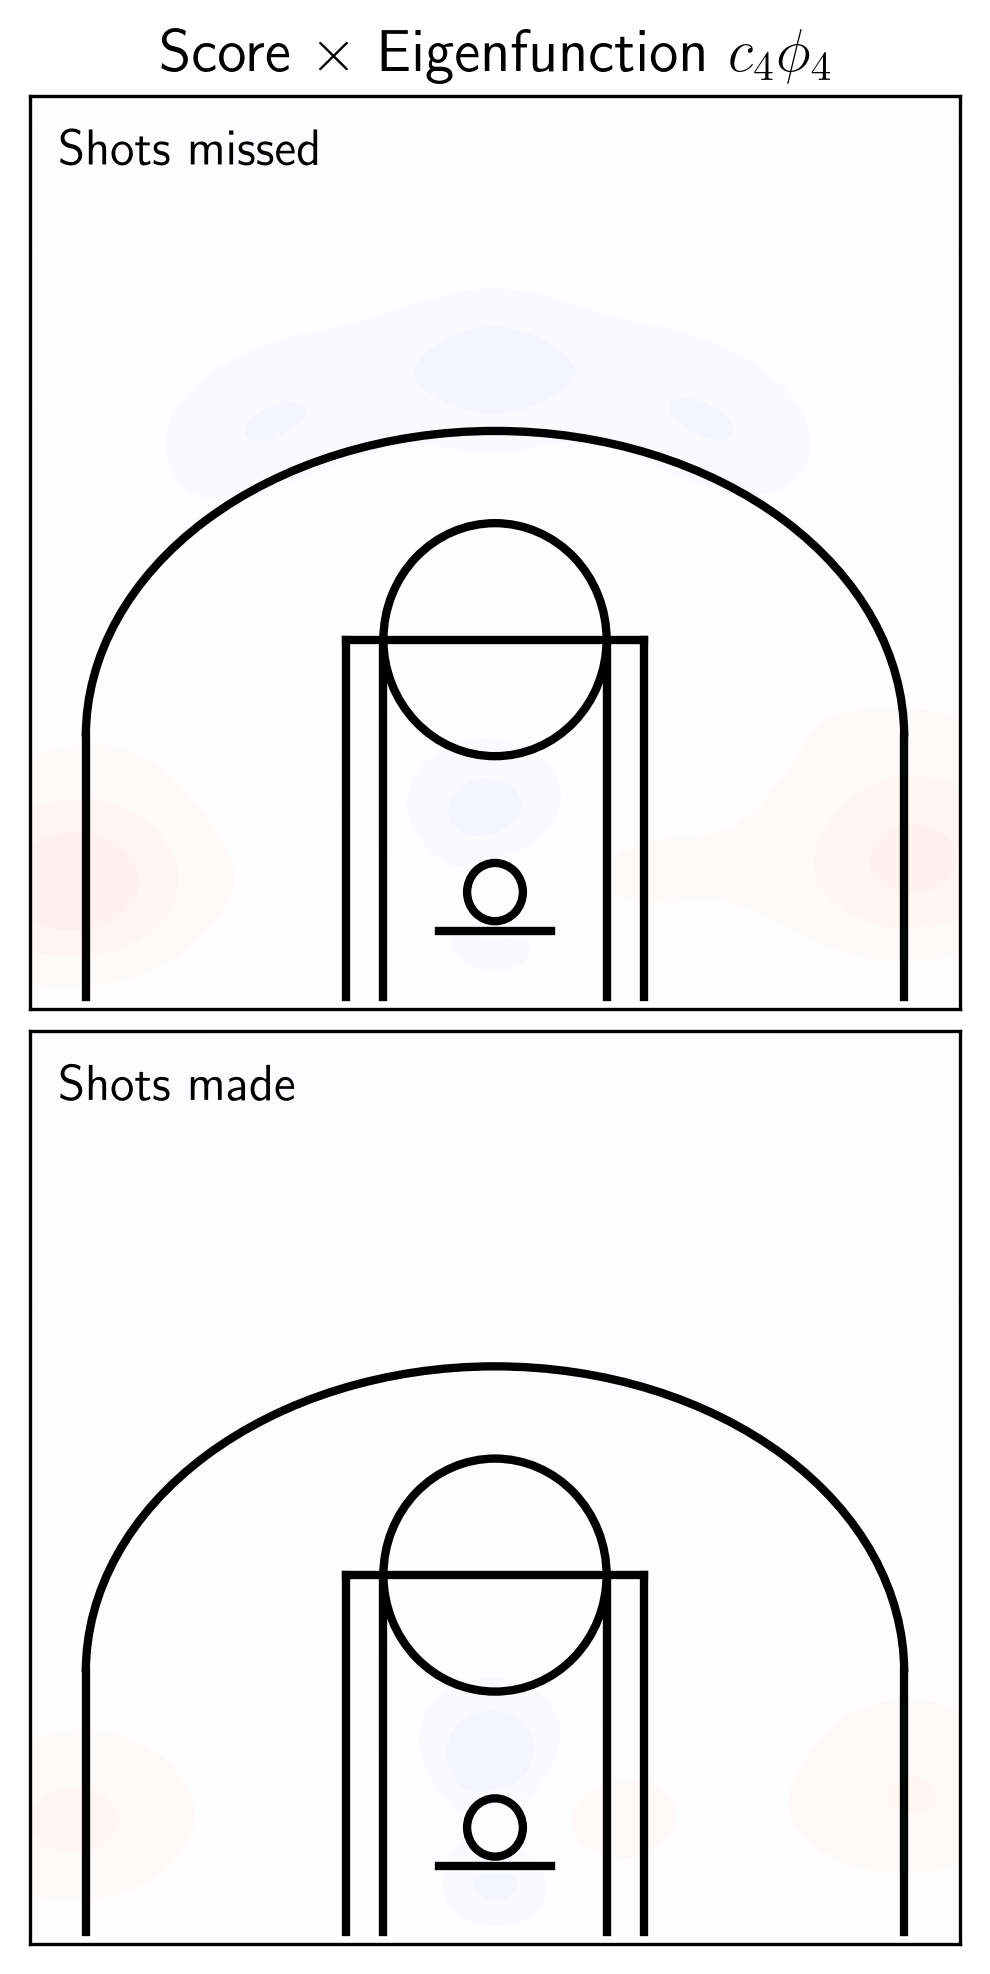

In [12]:
# Decomposition cluster
for idx_c, idx_p in enumerate(medoids):
    name = scores.iloc[idx_p]['PLAYER_NAME']

    for idx in range(4):
        fig, ax = plt.subplots(
            2, 1,
            figsize=(4, 8),
            facecolor='white',
            edgecolor='black',
            dpi=300
        )
        maxi = [np.max(np.abs(
            np.einsum('i, jk -> ijk', scores[idx].values, mfpca.eigenfunctions.data[pp][idx].values.squeeze())
        )) for pp in range(2)]
        maxi = max(maxi)

        ax[0].set_title(f"Score $\\times$ Eigenfunction $c_{{{idx + 1}}}\\phi_{{{idx + 1}}}$", fontsize='x-large')
        ax[0] = ShotCharts.shots_decomposition_chart(
            ax[0], mfpca, scores, idx, 0, name, 'Shots missed', maxi
        )
        ax[1] = ShotCharts.shots_decomposition_chart(
            ax[1], mfpca, scores, idx, 1, name, 'Shots made', maxi
        )

        plt.subplots_adjust(hspace=0.025)
        plt.savefig(
            f'./figures/kmedoids_{idx_c + 1}_eigenfunction_{idx + 1}-normalized-data-driven.eps',
            transparent=True, format='eps'
        )

[Text(0, 0, 'Guard'),
 Text(0, 1, 'Forward-Guard'),
 Text(0, 2, 'Forward'),
 Text(0, 3, 'Forward-Center'),
 Text(0, 4, 'Center')]

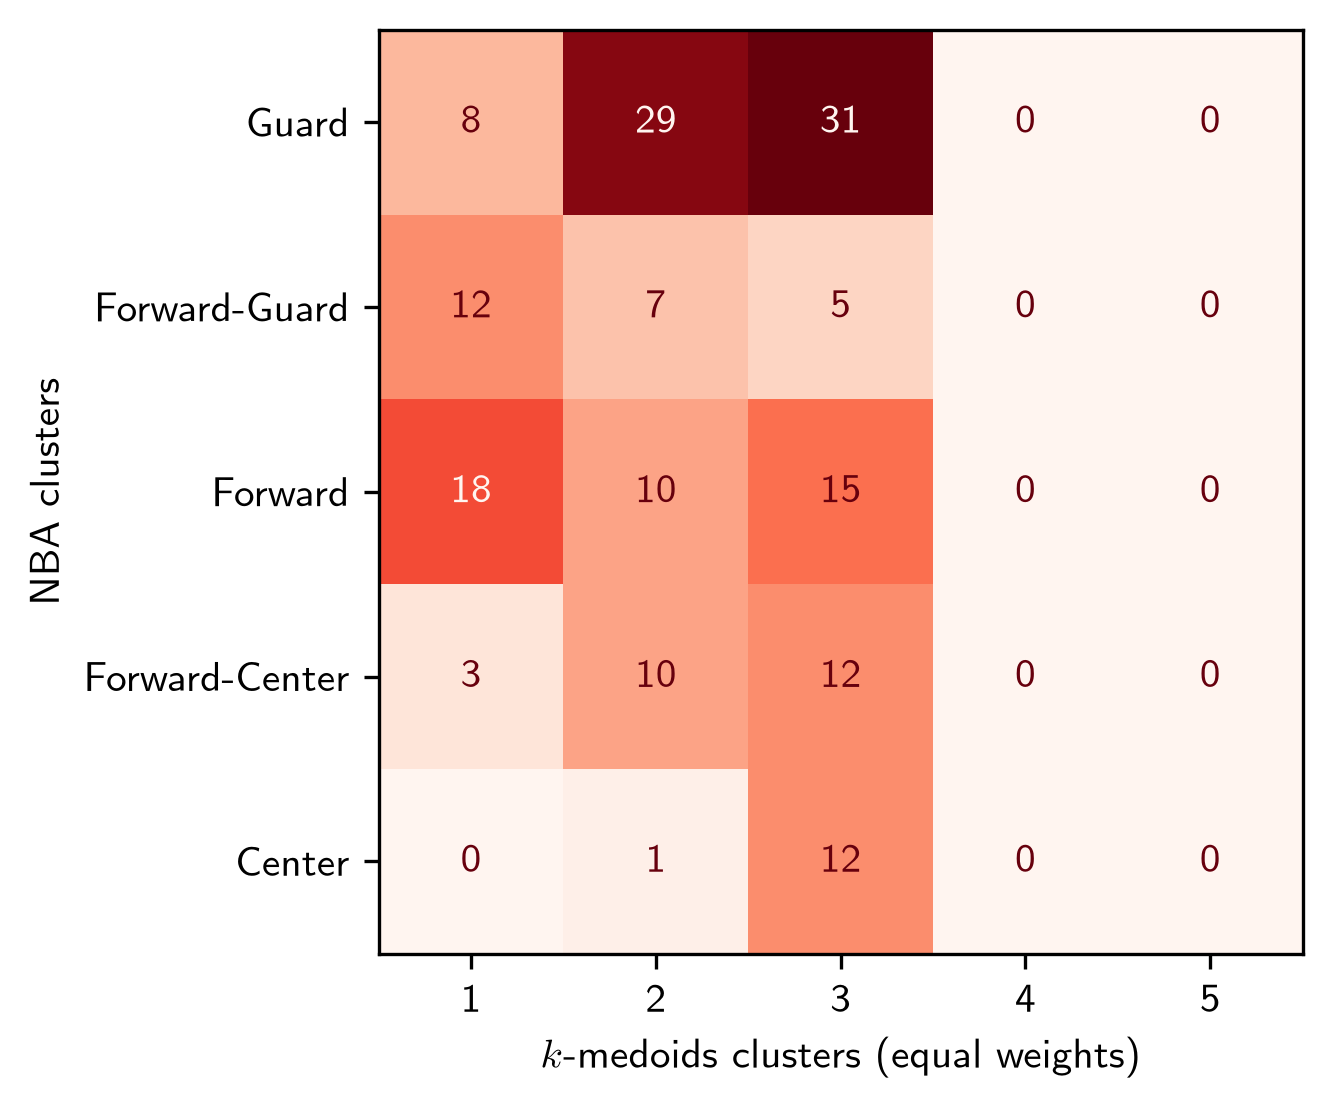

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

scores["POSITION_CAT"] = scores["POSITION_"].map(POSITION_CAT)

fig, ax = plt.subplots(
    1, 1,
    figsize=(6, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

confusion_mat = ConfusionMatrixDisplay.from_predictions(
    scores['POSITION_CAT'],
    clusters,
    cmap='Reds',
    colorbar=False,
    ax=ax
)
confusion_mat.ax_.set_xlabel("$k$-medoids clusters (equal weights)")
confusion_mat.ax_.set_ylabel("NBA clusters")
confusion_mat.ax_.set_yticklabels(['Guard', 'Forward-Guard', 'Forward', 'Forward-Center', 'Center'])
# plt.savefig(f'./figures/confusion_mat_kmedoids_no_weights.eps', transparent=True, format='eps')